In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('normal_data.csv', names=['timestamp', 'x', 'y', 'z'], header=None)
data = df['z'].values

mean_val = np.mean(data)
print(mean_val)


1.1168721348740294


In [2]:
df = pd.read_csv('anomaly_data.csv', names=['timestamp', 'x', 'y', 'z'], header=None)
data = df['z'].values

mean_val = np.mean(data)
print(mean_val)

1.1176214173228347


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# 设置参数
WINDOW_SIZE = 128  # 1.28秒一个窗口
FILES_NORMAL = ['normal_data.csv']
FILES_FAULT = ['anomaly_data.csv']

def prepare_data(file_list, label):
    segments = []
    for f in file_list:
        # names: 手动指定列名；header=None: 告诉 pandas 第一行不是表头
        df = pd.read_csv(f, names=['timestamp', 'x', 'y', 'z'], header=None)
        data = df['z'].values

        # 💥 终极修复：减去静态重力基准线（假设是 1.12，你可以根据 normal_data 算一下）
        # 这里不要除以标准差！只做减法！
        # 这样正常数据就变成了 0 ± 0.01，故障数据变成了 0 ± 0.15
        baseline = 1.1168
        data = data - baseline

        for i in range(0, len(data) - WINDOW_SIZE, WINDOW_SIZE // 2): # 50% 重叠
            segments.append(data[i : i + WINDOW_SIZE])
    return np.array(segments), np.array([label] * len(segments))

# 加载并合并
X_n, y_n = prepare_data(FILES_NORMAL, 0)
X_f, y_f = prepare_data(FILES_FAULT, 1)

X = np.concatenate([X_n, X_f]).reshape(-1, WINDOW_SIZE, 1)
y = np.concatenate([y_n, y_f])

# 划分训练集和测试集 (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"训练样本数: {len(X_train)}, 测试样本数: {len(X_test)}")

训练样本数: 394, 测试样本数: 99


In [4]:
model = models.Sequential([
    layers.Conv1D(16, 3, activation='relu', input_shape=(WINDOW_SIZE, 1)),
    layers.MaxPooling1D(2),
    layers.Conv1D(32, 3, activation='relu'),
    layers.GlobalAveragePooling1D(), # 💥 降维打击的核心
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 开始训练
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9594 - loss: 0.6835 - val_accuracy: 1.0000 - val_loss: 0.6744
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.6609 - val_accuracy: 1.0000 - val_loss: 0.6441
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9086 - loss: 0.6216 - val_accuracy: 1.0000 - val_loss: 0.5937
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.5580 - val_accuracy: 1.0000 - val_loss: 0.5204
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.4778 - val_accuracy: 1.0000 - val_loss: 0.4375
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.3952 - val_accuracy: 1.0000 - val_loss: 0.3591
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.3203 - val_accuracy: 1.0000 - val_loss: 0.2898
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.2561 - val_accuracy: 1.0000 - val_loss: 0.2304
Ep

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

--- 混淆矩阵 (Confusion Matrix) ---
预测正常且正确: 51 | 漏报(故障变正常): 0
误报(正常变故障): 0 | 预测故障且正确: 48


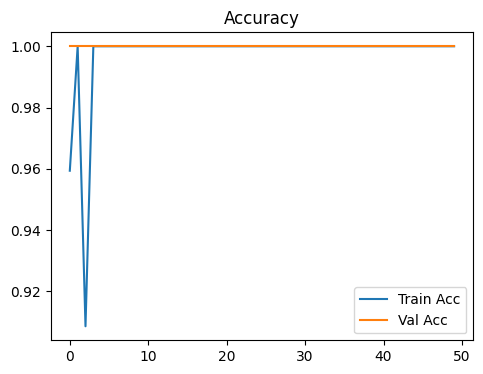

In [5]:
# 绘制训练曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

# 预测结果
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
print("\n--- 混淆矩阵 (Confusion Matrix) ---")
print(f"预测正常且正确: {cm[0][0]} | 漏报(故障变正常): {cm[1][0]}")
print(f"误报(正常变故障): {cm[0][1]} | 预测故障且正确: {cm[1][1]}")


In [6]:
import tensorflow as tf
import os

print("🚀 开始进行 TinyML 降维打击...")

# ==========================================
# 1. 将 Keras 模型转换为 TensorFlow Lite 格式
# ==========================================
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 开启默认优化（核心！这会把 float32 参数压缩，极其节省空间）
# converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# 保存为二进制文件
with open('pdm_motor_model.tflite', 'wb') as f:
    f.write(tflite_model)

tflite_size = os.path.getsize('pdm_motor_model.tflite')
print(f"✅ TFLite 模型瘦身完成！体积仅为: {tflite_size} 字节 ({tflite_size/1024:.2f} KB)")


# ==========================================
# 2. 将二进制模型翻译为 C++ 头文件
# ==========================================
def hex_to_c_array(hex_data, var_name):
    """将二进制数据转换为 C 语言的十六进制数组格式"""
    c_str = f"// 自动生成的工业 PdM 模型\n"
    c_str += f"// 包含 1665 个参数的 1D CNN\n\n"
    c_str += f"const unsigned char {var_name}[] = {{\n"

    # 转换为 0x00 格式
    hex_array = [f"0x{b:02x}" for b in hex_data]

    # 每行打印 12 个字节，保持代码整洁
    for i in range(0, len(hex_array), 12):
        c_str += "  " + ", ".join(hex_array[i:i+12]) + ",\n"

    c_str += f"}};\n\n"
    c_str += f"const unsigned int {var_name}_len = {len(hex_data)};\n"
    return c_str

# 生成 model_data.h 文件
with open('model_data.h', 'w') as f:
    f.write(hex_to_c_array(tflite_model, "g_pdm_model"))

print("✅ C++ 头文件 model_data.h 已生成！请在 Colab 左侧文件栏下载。")

🚀 开始进行 TinyML 降维打击...
Saved artifact at '/tmp/tmp9r95vwg6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136655066929424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136655066930576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136655066928464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136655066928080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136655066927888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136655066930000: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ TFLite 模型瘦身完成！体积仅为: 10984 字节 (10.73 KB)
✅ C++ 头文件 model_data.h 已生成！请在 Colab 左侧文件栏下载。
